## ECC implementation and visualization

Gerard Consuelo, Atay Moya, Larry Shields

In [49]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


### Overview

---

RSA is the most widely accepted public-key scheme. It is used for encryption, digital signatures, and symmetric key exchange. Though quite powerful in that it is computationally impossible to reverse its process, it is very computational heavy. Its key sizes are enormous at around 512 bits, and must keep increasing with the rapid development of technology. 

Elliptical Curve Cryptography (ECC) is a method of cryptography based on elliptical curves and the difficulty in computing the elliptic curve discrete logarithmic problem. It offers the same security as RSA, with the differnece that it is extremely efficient for smaller bit sizes, where a 256 -bit key for ECC provides as much security as a 3072-bit key using RSA.


### The Elliptic Curve Discrete Logarithmic Problem

---

In RSA, recall that the core equation we have was starting with two large prime numbers, p and q, to get our modulo. 
$$N = p \cdot q$$

Then we would use Euler's Totient function (p-1)(q-1) to narrow it down to a finite amount of numbers. 
$$\phi(N) = (p-1)(q-1)$$

Then, we pick a public key e in between 1 and the totient. 
$$1 < e < \phi(N) \quad \text{where} \quad \gcd(e, \phi(N)) = 1$$

To achieve the private key d, we would find the public key's inverse through the modulo stuff. 
$$d \equiv e^{-1} \pmod{\phi(N)}$$

To encrypt, the ciphertext (c) is m^e and to decrypt, the plaintext (m) should be the result from c^d.
$$\text{Encryption: } c \equiv m^e \pmod N$$
$$\text{Decryption: } m \equiv c^d \pmod N$$

Here is a really simplified version of what we do for RSA. This is bruteforcing.


In [50]:
def do_rsa(p, q, e, M):
    # looking for n and d
    n = p * q
    print(f"n = p * q = {p} * {q} = {n}")
    phi_t = (p-1) * (q-1)
    print(f"phi(t) = (p-1)*(q-1) = {p-1} * {q-1} = {phi_t}")

    d = 1
    while e * d % phi_t != 1:
        d += 1
    print(f"(e * d) mod n = 1 => ({e}*d) mod {phi_t} = 1, so d = {d}")

    C = pow(M, e) % n
    print(f"encryption result (C): {C}")
    decryption = pow(C, d) % n

    print(f"decryption result (M): {decryption} which is the same as M = {M}")


print("---a---")
do_rsa(3, 11, 7, 5)

---a---
n = p * q = 3 * 11 = 33
phi(t) = (p-1)*(q-1) = 2 * 10 = 20
(e * d) mod n = 1 => (7*d) mod 20 = 1, so d = 3
encryption result (C): 14
decryption result (M): 5 which is the same as M = 5


ECC follows a similar process, but with points on the elliptic curve.
$$y^2 \equiv x^3 + ax + b \pmod p$$

The core equation we start with for ECC is $Q = k \cdot G$, which is the elliptic curve discrete logarithmic problem. 
$$Q = k \cdot G$$

In this equation, $k$ is a scalar, $G$ is a publicly-known generator point, and $Q$ is the resulting public key point. 
$$k \in \{1, 2, \dots, n-1\} \quad \text{(where } n \text{ is the order of the curve)}$$
$$G, Q \in E(\mathbb{F}_p)$$

For encryption, $k$ is our private key, $Q$ is our public key, and $G$ is a publicly-known constant generator point.

Before implementing, let's first go over the algebra, building the concept from the ground up. 

### Algebra

---

Before we go over algebra, we will first go over the parameters. 
The domain parameters for an elliptic curve over $F_p$ are $p$, $a$, $b$, $G$, $n$, and $h$.

- $p$ is the prime number that defines the finite field $F_p$, or the number we mod everything- with. It must be prime to allow a set of numbers that can be added, subtracted, multiplied, and divided.

- $a$ and $b$ are the parameters that define the curve $y^2 = x^3 + ax + b$ over $F_p$.

- $G$ is the generator point $(x_G, y_G)$, a point on the elliptic curve chosen for cryptographic operations.

- $n$ is the order of each subgroup, meaning when we start at the point G, we do n "jumps" or additions to get back to the identity value. 

    - The scalar for point multiplication is chosen as a number between $0$ and $n - 1$.

- $h$ is the cofactor, where $h = \#E(F_p) / n$. $\#E(F_p)$ is the number of points on an elliptic curve. The lower the number, the higher the amount of subgroups a potential hacker may have to loop through. What most have is 8 and the most secure is 1.

Let's define these in our code first before moving forward. 

In [51]:
# we use INF as a special Elliptic Curve zero point 
INF = None


# elliptic curve, where y^2 = x^3 + ax + b
# p defines the finite field
class Curve:

    def __init__(self, p, a, b):
        self.p = p
        self.a = a
        self.b = b

curve = Curve(p=17, a=2, b=2)
G = (5, 1)
k = 7

With those parameters defined, we can look at the algebra of an elliptic curve, namely point addition and point doubling.

**Point Addition**
This operation is defined as $C = A + B$, where $B$, $A$, and the resulting point $C$ all lie on the curve, or are the identity element, denoted as $\mathcal{O}$ (often referred to as the identity value). 

Elliptic curves have a geometric property where drawing a straight line through any 2 points ($B$ and $A$) will intersect the curve at exactly one third point, which we call $-C$. To find the actual result of $A + B$, you take that third intersection point and **reflect it across the x-axis** to get $C$. 

An edge case occurs when $B = -A$ (meaning they share the same x-coordinate but have opposite y-coordinates). The line through them is purely vertical, meaning it never intersects the curve a third time. Instead, we say it intersects at infinity, resulting in our identity value: $A + (-B) = \mathcal{O}$. 

Assuming our curve follows the standard form $y^2 = x^3 + ax + b$, and $A = (x_1, y_1)$ and $B = (x_2, y_2)$, here are the equations to find $C = (x_3, y_3)$:

$$s = \frac{y_2 - y_1}{x_2 - x_1}$$

$$x_3 = s^2 - x_1 - x_2$$

$$y_3 = s(x_1 - x_3) - y_1$$

**Point Doubling**
Building on top of addition, this is simply calculating $2A = A + A$. Geometrically, since $A$ and $B$ are the exact same point, you cannot draw a standard line between them. Instead, you draw the tangent line to the curve exactly at point $A$. This tangent line will intersect the curve at another point, $-2A$. Just like in addition, you reflect this point across the x-axis to find $2A$.

$2A$ results in the identity value $\mathcal{O}$ if $A$ is already the identity value, or if the y-coordinate of $A$ is exactly $0$ (which makes the tangent line perfectly vertical).

Using the same curve parameters, here are the equations for point doubling to find $2A = (x_3, y_3)$:

$$s = \frac{3x_1^2 + a}{2y_1}$$

$$x_3 = s^2 - 2x_1$$

$$y_3 = s(x_1 - x_3) - y_1$$

Here is this spelled out in code:

In [52]:
# we do not need two different functions for point addition and doubling since code would be the same
def point_add(p1, p2, curve):

    if p1 is INF:
        return p2
    if p2 is INF:
        return p1

    x1, y1 = p1
    x2, y2 = p2

    if x1 == x2:
        return INF

    if p1 == p2:
        #if we only have one point, we use the tangent line using the derivative
        slope_top = 3 * x1 * x1 + curve.a
        slope_bottom = 2 * y1
    else:
        slope_top = y2 - y1
        slope_bottom = x2 - x1

    # since the slope is a fraction, in a finite field of integers we need to use the modular inverse
    slope = slope_top/slope_bottom
    x3 = (slope * slope - x1 - x2)
    y3 = (slope * (x1 - x3) - y1)
    return (x3, y3) 



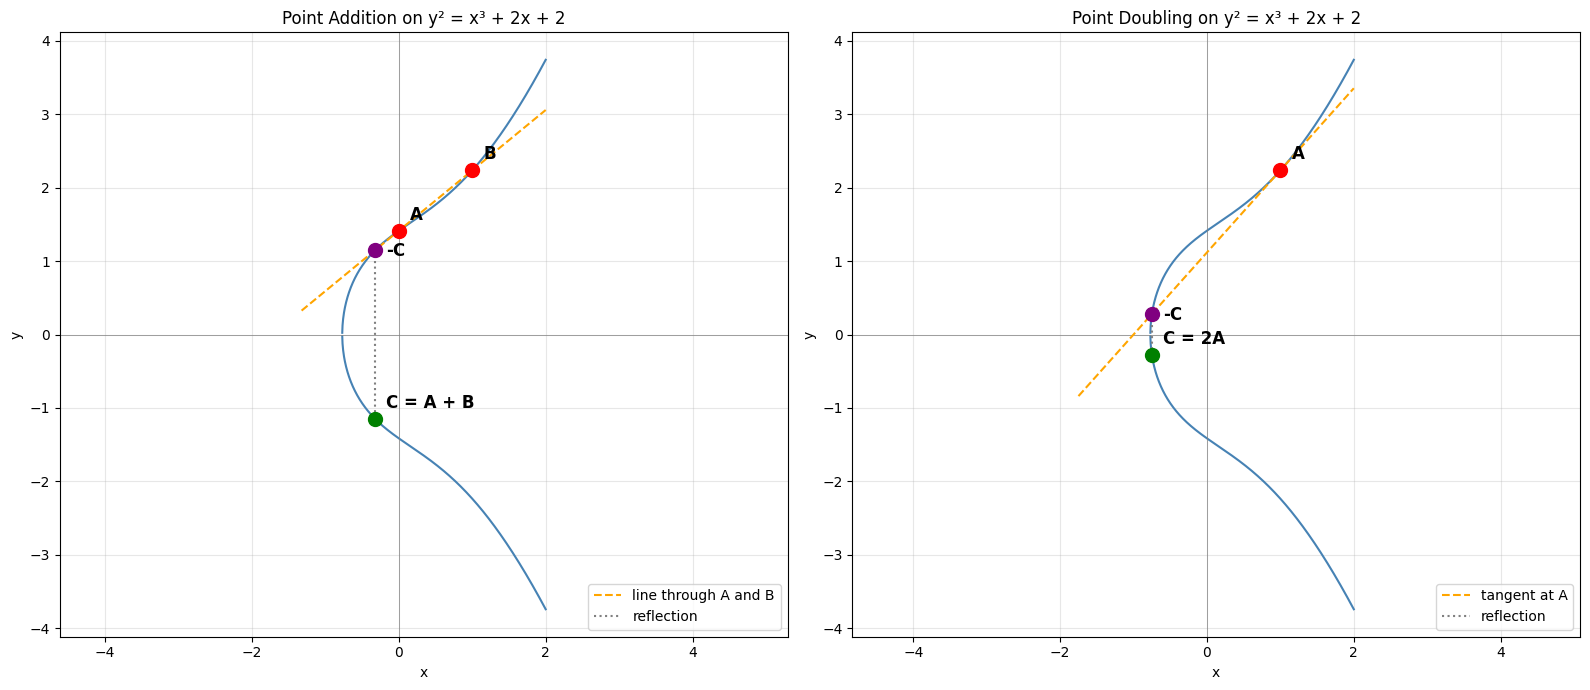

In [53]:
import math
import matplotlib.pyplot as plt
from visualization import plot_point_addition

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

A = (0, math.sqrt(2))
B = (1, math.sqrt(5))
plot_point_addition(A, B, curve, ax=ax1, x_range=(-2, 2))

A = (1, math.sqrt(5))
plot_point_addition(A, A, curve, ax=ax2, x_range=(-2, 2))

plt.tight_layout()
plt.show()

### Finite Field

---

However, the numbers can get way too large, leading to round-off errors and sluggishness. To remedy this, we use a modulo over $p$, allowing an infinite number of inputs but a finite number of outputs. There will be overlaps, making it much harder to reverse.

So the equations will look like this:

**Point Addition ($C = A + B$)**

points $A = (x_1, y_1)$ and $B = (x_2, y_2)$:

$$s = (y_2 - y_1) \cdot (x_2 - x_1)^{-1} \pmod{p}$$
$$x_3 = s^2 - x_1 - x_2 \pmod{p}$$
$$y_3 = s(x_1 - x_3) - y_1 \pmod{p}$$

**Point Doubling ($2A$)**

point $A = (x_1, y_1)$ (where $y_1 = 0$):

$$s = (3x_1^2 + a) \cdot (2y_1)^{-1} \pmod{p}$$
$$x_3 = s^2 - 2x_1 \pmod{p}$$
$$y_3 = s(x_1 - x_3) - y_1 \pmod{p}$$

In [54]:
# we do not need two different functions for point addition and doubling since code would be the same
def point_add(p1, p2, curve):

    if p1 is INF:
        return p2
    if p2 is INF:
        return p1

    x1, y1 = p1
    x2, y2 = p2

    if x1 == x2 and (y1 + y2) % curve.p == 0: ## added the mod
        return INF

    if p1 == p2:
        slope_top = 3 * x1 * x1 + curve.a
        slope_bottom = 2 * y1
    else:
        slope_top = y2 - y1
        slope_bottom = x2 - x1

    slope = (slope_top/slope_bottom) % curve.p
    x3 = (slope * slope - x1 - x2) % curve.p
    y3 = (slope * (x1 - x3) - y1) % curve.p
    return (x3, y3)

### Modular Arithmetic

---

Because now we are in a finite field, the algebra changes as well so the regular addition, subtraction, multiplication, and division within `point_add()` currently is incorrect. Let's take a look at how all of these work. For these operations, we assume that the inputs are all within the modulo already.

Let's start basic with the addition and subtraction, which don't really change that much. Think about these as a basic wrap around. 

**Addition**
When adding two numbers in a finite field, the worst-case bit length increases by 1 (e.g., an 8-bit number might overflow into a 9-bit number). To keep the result within the field, we simply subtract the modulo $p$ from the addition.
* **Example:** $15 + 20 = 35$. Since $35 > 23$, we do $35 - 23 = 12$.

**Subtraction**
Similar to addition, subtraction worst case brings the bit length down or the value to become negative. To keep the result within the field, we simply add the modulo $p$ to the result.
* **Example:** $15 - 20 = -5$. Since $-5 < 0$, we do $-5 + 23 = 18$.

**Multiplication (Double-and-Add Algorithm)**

This is the core of the ECC encryption. Recall that ECC involves the equation $Q = k \cdot G$, multiplying $G$ by the scalar $k$. We could add it $k$ times, but this would be quite slow for really large numbers. 
ECC normally uses 200 bit integers, meaning around 2^200 integers for the private key. Looping through every single one would take a while, so instead of that, we use the double and method using bit shifts for maximum efficiency. 

Instead of multiplying two large numbers directly which can cause the bit length to overflow, we can rely on bitwise properties using the "double-and-add" method. We follow these steps.
1.  Get the number we multiply by, m, and get its bit representation.
2.  Loop through its bits
3.  if the bit is "on", then we add m to a separate value.
4.  double m (since every shift is *2 basically)

Here is a small example:

$15 \cdot 20 \bmod 23$

$B = 20$ in binary is **`10100`**

`Total = 0` (This will accumulate our final answer)
`Current_A = 15` (We will continuously double this value modulo 23)

**Bit 1 (Rightmost bit) = 0**
  * Since the bit is **0**, we DO NOT add `Current_A` to our `Total`.
  * `Total` remains $0$.
  * DOUBLE `Current_A` for the next step: $(15 \times 2) \pmod{23} = 30 \pmod{23} = 7$.

**Bit 2 = 0**
  * Since the bit is **0**, we DO NOT add `Current_A` to our `Total`.
  * `Total` remains $0$.
  * DOUBLE `Current_A` for the next step: $(7 \times 2) \pmod{23} = 14 \pmod{23} = 14$.

**Bit 3 = 1**
  * Since the bit is **1**, we ADD `Current_A` to our `Total`.
  * `Total` = $(0 + 14) \pmod{23} = 14$.
  * DOUBLE `Current_A` for the next step: $(14 \times 2) \pmod{23} = 28 \pmod{23} = 5$.

**Bit 4 = 0**
  * Since the bit is **0**, we DO NOT add `Current_A` to our `Total`. 
  * `Total` remains $14$.
  * DOUBLE `Current_A` for the next step: $(5 \times 2) \pmod{23} = 10 \pmod{23} = 10$.

**Bit 5 (Leftmost bit) = 1**
  * Since the bit is **1**, we ADD `Current_A` to our `Total`.
  * `Total` = $(14 + 10) \pmod{23} = 24 \pmod{23} = 1$.
  * *(We stop doubling `Current_A` here as we have processed all the bits).*
  

Here is it what the code would look like:

In [55]:
def scalar_multiply(k, point, curve):
    result = INF
    addend = point

    # this uses the double and algorithm in o(n) where n = log2(k)
    # from https://www.youtube.com/watch?v=u1VRbo_fhC8&list=PLxP0p--aBHmIAeOBX1lkpTn-wAbAimg8-&index=4

    while k:
        if k & 1:
            result = point_add(result, addend, curve)
        addend = point_add(addend, addend, curve)
        k >>= 1

    return result


**Division using The Extended Euclidean Algorithm**

Lastly, we have division. In modular arithmetic (a finite field defined by a prime $P$), standard division does not exist. Instead of dividing $A$ by $B$ (calculating $A / B$), we must compute $A \cdot B^{-1} \pmod P$, where $B^{-1}$ is the **modular multiplicative inverse** of $B$. 

Finding this inverse relies on the **Extended Euclidean Algorithm (EEA)**. Here is how the math unfolds:

* At its core, the standard Euclidean algorithm efficiently computes the Greatest Common Divisor (GCD) of two numbers. It is based on the principle that the GCD of two numbers does not change if the larger number is replaced by its remainder when divided by the smaller number. 
  * To find the GCD of two numbers, $A$ and $B$ (assuming $A > B$):
    1. Divide $A$ by $B$ to find the quotient $Q$ and the remainder $R$. (Mathematically: $A = Q \cdot B + R$).
    2. If the remainder $R = 0$, then your current $B$ is the GCD. You are done.
    3. If $R \neq 0$, shift your numbers: replace $A$ with $B$, and replace $B$ with $R$. 
    4. Repeat the division with the new $A$ and $B$ until the remainder hits $0$. The last non-zero remainder (which is the divisor at the final step) is the GCD.
  * **Example:** $\gcd(252, 105)$.
    * **Step 1:** $252 \div 105 = 2$ with a remainder of **$42$**. 
      *(Equation: $252 = 2 \cdot 105 + 42$)*
    * **Step 2:** Shift the numbers. Our new division is $105 \div 42$.
      $105 \div 42 = 2$ with a remainder of **$21$**. 
      *(Equation: $105 = 2 \cdot 42 + 21$)*
    * **Step 3:** Shift the numbers again. Our new division is $42 \div 21$.
      $42 \div 21 = 2$ with a remainder of **$0$**. 
      *(Equation: $42 = 2 \cdot 21 + 0$)*
    * **Result:** Since the remainder is now $0$, the algorithm stops. The last non-zero remainder (our final divisor) is $21$. Therefore, $\gcd(252, 105) = 21$.
* The *Extended* version of the algorithm goes a step further by calculating the coefficients (often called Bézout coefficients) that satisfy Bézout's Identity. This theorem states that for any two integers $B$ and $P$, there exist integer coefficients $m$ and $n$ such that:
  $$B \cdot m + P \cdot n = \gcd(B, P)$$
* In elliptic curve cryptography, our modulo $P$ is a prime number. Because $P$ is prime, it has no positive divisors other than 1 and itself. Therefore, as long as $B$ is not $0$, the GCD of $B$ and $P$ is guaranteed to be exactly 1. Bézout's identity simplifies perfectly to:
  $$B \cdot m + P \cdot n = 1$$
* If we take the modulo $P$ of both sides of this equation, the term $P \cdot n$ becomes exactly $0$ (because any multiple of $P$ is $0 \pmod P$). The equation isolates our terms to:
  $$B \cdot m \equiv 1 \pmod P$$
* By mathematical definition, a number multiplied by its inverse equals 1. Therefore, the coefficient $m$ (which the EEA calculates for us) is exactly our modular inverse, $B^{-1}$! 

Once we use the EEA to find $m$, our original division problem ($A / B$) simply becomes an easy multiplication problem: $A \times m \pmod P$.


Here is the code spelled out:

In [56]:
# uses the extended euclidean algorithm
def mod_inverse(value, p):

    value %= p
    if value == 0:
        return -1

    old_r, r = value, p
    old_s, s = 1, 0

    while r:
        quotient = old_r // r
        old_r, r = r, old_r - quotient * r
        old_s, s = s, old_s - quotient * s

    if old_r != 1:
        return -1

    return old_s % p

Perfect! We now have all of the basic algebra to rewrite our `point_add()` method. Here is what the finalized code would look like:

In [57]:
# we do not need two different functions for point addition and doubling since code would be the same
def point_add(p1, p2, curve):

    if p1 is INF:
        return p2
    if p2 is INF:
        return p1

    x1, y1 = p1
    x2, y2 = p2

    if x1 == x2 and (y1 + y2) % curve.p == 0:
        return INF

    if p1 == p2:
        #if we only have one point, we use the tangent line using the derivative
        slope_top = 3 * x1 * x1 + curve.a
        slope_bottom = 2 * y1
    else:
        slope_top = y2 - y1
        slope_bottom = x2 - x1

    # since the slope is a fraction, in a finite field of integers we need to use the modular inverse
    slope = (slope_top * mod_inverse(slope_bottom, curve.p)) % curve.p
    x3 = (slope * slope - x1 - x2) % curve.p
    y3 = (slope * (x1 - x3) - y1) % curve.p
    return (x3, y3)

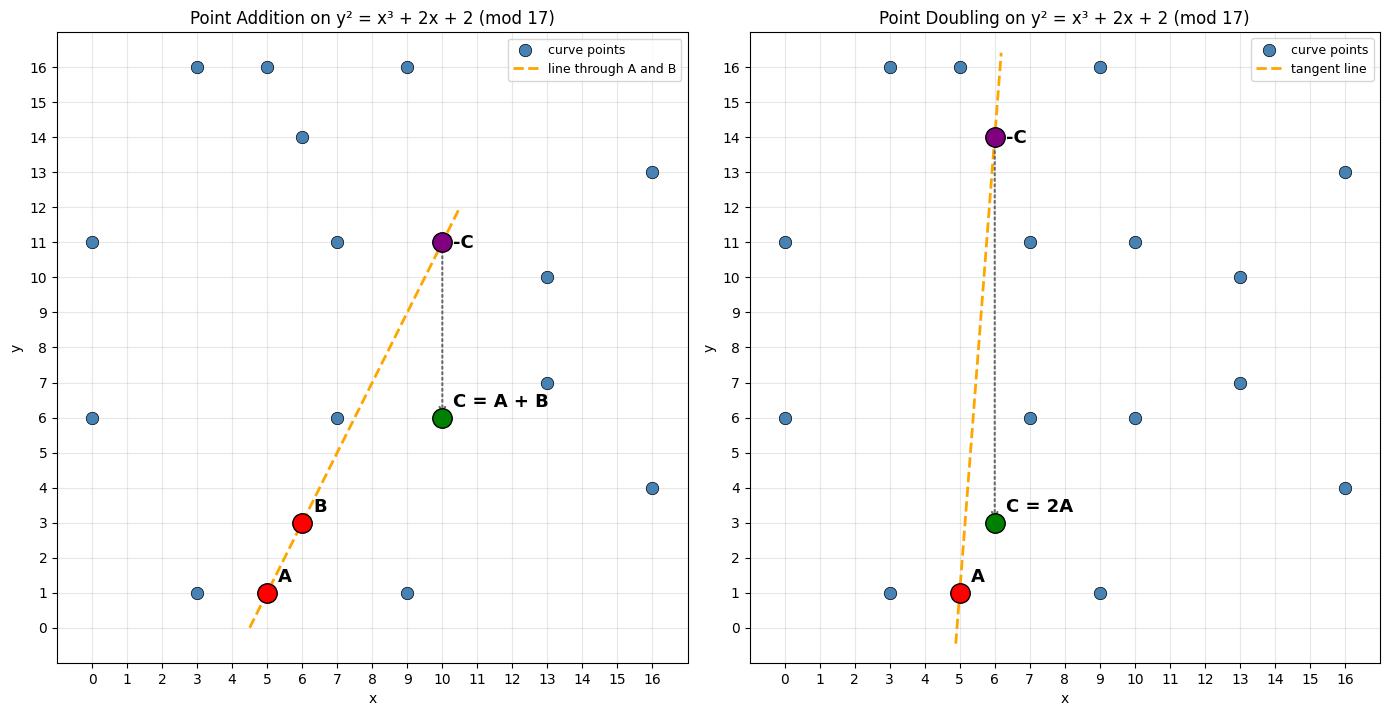

In [58]:
import importlib
import matplotlib.pyplot as plt
import visualization
importlib.reload(visualization)
from visualization import plot_point_addition_ff

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# point addition: A + B
plot_point_addition_ff(G, (6, 3), curve, ax=ax1)

# point doubling: 2A
plot_point_addition_ff(G, G, curve, ax=ax2)

plt.tight_layout()
plt.show()

### Scalar multiplication and the discrete log problem

---

Now we put it all together. ECC's security rests on the equation $kG = Q$, where $G$ is a public generator point, $k$ is the private key (a scalar), and $Q$ is the public key. Computing $Q$ from $k$ and $G$ is fast — we use the double-and-add algorithm above. But going the other way — recovering $k$ from $G$ and $Q$ — is the **elliptic curve discrete logarithm problem**, and is computationally infeasible for large primes.

To get a feel for *why* it is hard, we visualize the path $G \to 2G \to 3G \to \dots \to kG$ on a slightly bigger curve: $y^2 = x^3 + 2x + 2 \pmod{257}$. We connect consecutive multiples with line segments. Even on this small curve the trajectory bounces around the field unpredictably — there is no useful pattern an attacker could follow to back out $k$.

Private key (k): 125
Public key  (Q = k·G): (0, 197)


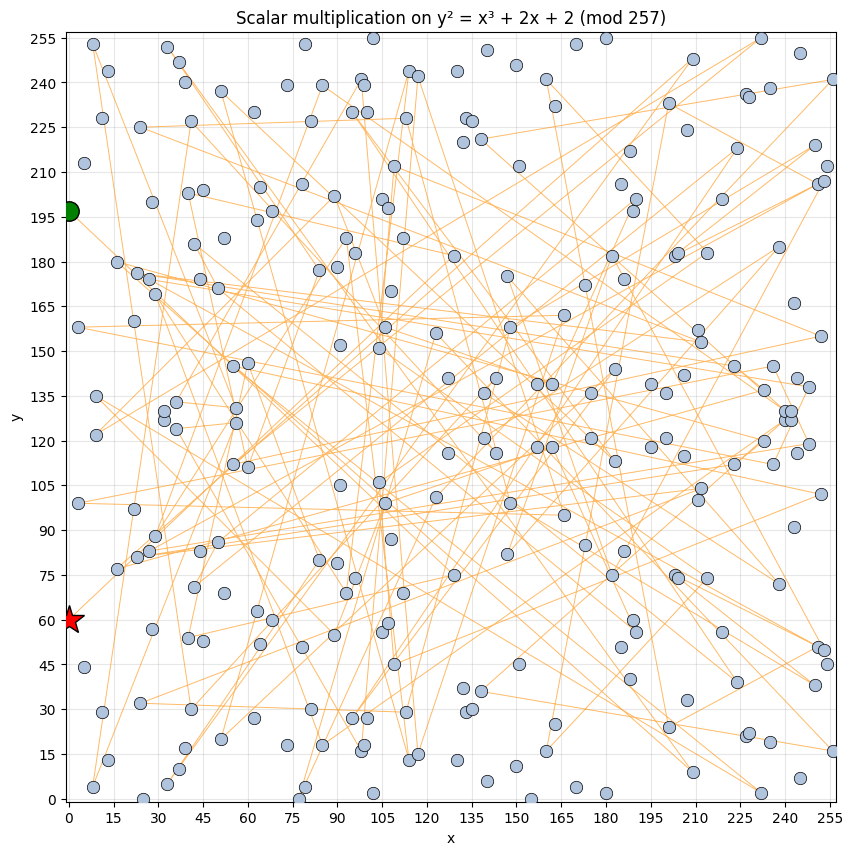

In [59]:
import importlib
import visualization
importlib.reload(visualization)
from visualization import plot_scalar_multiplication_ff

# bigger curve so the path can really wander: y^2 = x^3 + 2x + 2 mod 257
# this curve has 252 affine points; the generator G below has order 126
big_curve = Curve(p=257, a=2, b=2)
big_G = (0, 60)

# k is our private key / scalar. picking k = 125 walks the full subgroup
# generated by G (everything short of returning to the identity)
k = 125

plot_scalar_multiplication_ff(big_G, k, big_curve, point_add)

public_key = scalar_multiply(k, big_G, big_curve)
print(f"Private key (k): {k}")
print(f"Public key  (Q = k·G): {public_key}")